# S01: From Molecules to Labeled Graphs

This talktorial introduces molecular representations for SynEdu: RDKit [\[1\]](#6.-References) molecules, SMILES strings [\[2\]](#6.-References), and explicit NetworkX labeled graphs. The focus is on what chemical information is preserved, what can be lost, and why representation choices matter for later graph-matching and reaction-rule tasks, [\[3\]](#6.-References), [\[4\]](#6.-References).


## Aim of this talktorial

1. Build a compact **RDKit** foundation for parsing, inspecting, and canonicalizing molecules.
2. Understand **SMILES** as a graph encoding with choices around aromaticity, hydrogens, and stereochemistry.
3. Convert molecules into **labeled molecular graphs** and test round-trip behavior between RDKit and NetworkX.

---

## Learning outcomes

After completing this talktorial you will be able to:

- Parse SMILES with **RDKit** and understand what sanitization does.  
- Produce canonical SMILES.
- Convert SMILES into **labeled molecular graphs** (atoms → nodes, bonds → edges).  
- Perform a **round-trip conversion** between RDKit and NetworkX and identify which chemical details are preserved or lost.  
- Explain why **symmetry** and **label design** are critical for reaction rule discovery and application.

---

## Outline

- [0. Setup & data](#0.-Setup-&-data)
- [1. Introduction to RDKit](#1.-Introduction-to-RDKit)
- [2. SMILES](#2.-SMILES)
- [3. Molecular Graph representation](#3.-Molecular-Graph-representation)
- [4. Discussion](#4.-Discussion)
- [5. Quiz](#5.-Quiz)
- [6. References](#6.-References)

<a id="0-setup--data"></a>

## 0. Setup & data

In [1]:
%matplotlib inline
import rdkit
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from synedu.Utils.vis import draw_molecular_graph  # for visualization

print("RDKit version:", rdkit.__version__)
print("NetworkX version:", nx.__version__)

DATA_DIR = Path("data")
CSV_PATH = DATA_DIR / "molecules.csv"
df = pd.read_csv(CSV_PATH)
display(df.head(5))

RDKit version: 2025.09.3
NetworkX version: 3.6.1


,smiles,name
0,CCO,ethanol
1,CCCl,chloroethane
2,CCOCC,diethyl ether
3,O,water
4,NCC(=O)O,glycine


<a id="s01-rdkit"></a>

## 1. Introduction to RDKit

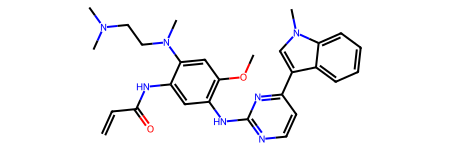

In [2]:
from rdkit import Chem

smiles = "CN1C=C(C2=CC=CC=C21)C3=NC(=NC=C3)NC4=C(C=C(C(=C4)NC(=O)C=C)N(C)CCN(C)C)OC"  # NSCLC TKI
osimertinib = Chem.MolFromSmiles(smiles)
osimertinib  # you can see the figure of osimertinib

Use `IPythonConsole` to render RDKit atom indices on molecular structures.

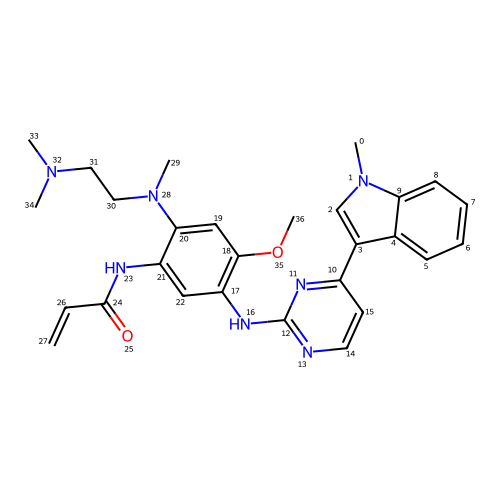

In [3]:
from rdkit.Chem.Draw import IPythonConsole
from typing import Tuple


def set_rdkit_draw_options(
    *,
    atom_indices: bool = True,
    bond_indices: bool = False,
    mol_size: Tuple[int, int] = (500, 500),
):
    """
    Configure RDKit molecule rendering in Jupyter notebooks.

    Parameters
    ----------
    atom_indices : bool, optional
        Whether to display RDKit atom indices (0-based).
    bond_indices : bool, optional
        Whether to display bond indices.
    mol_size : tuple[int, int], optional
        Size of rendered molecule in pixels (width, height).
    """
    IPythonConsole.drawOptions.addAtomIndices = atom_indices
    IPythonConsole.drawOptions.addBondIndices = bond_indices
    IPythonConsole.molSize = mol_size


set_rdkit_draw_options()
osimertinib  # Now you can see the indice of each atom, start from 0

RDKit’s `Draw.MolsToGridImage` allows you to display a list of molecules
as a grid for rapid visual inspection and comparison.

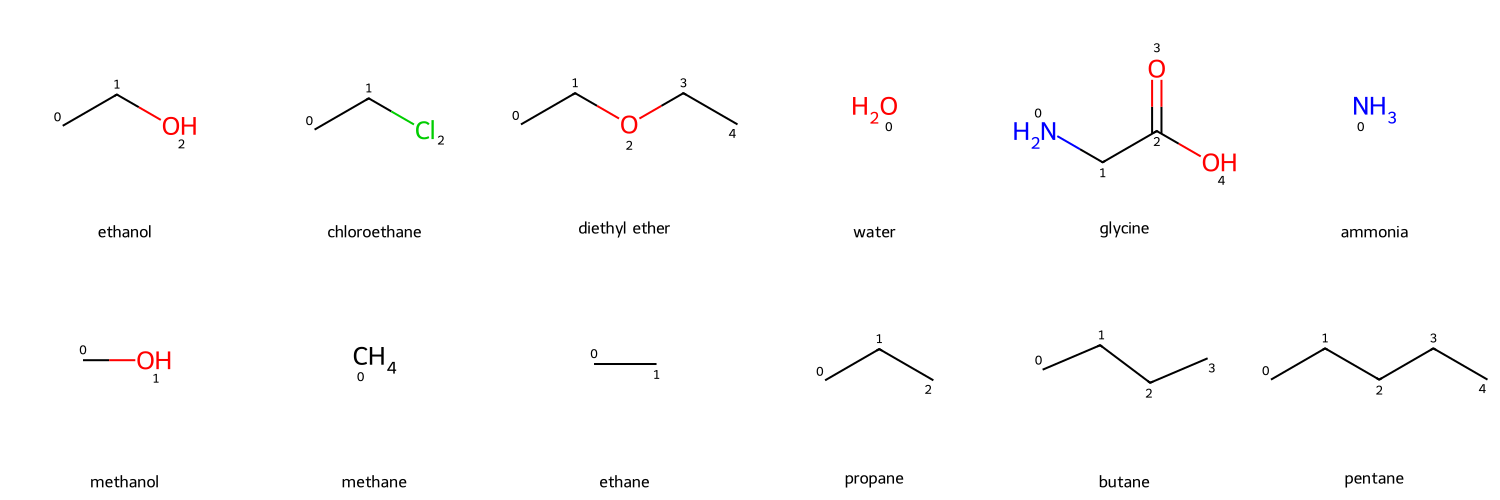

In [4]:
from rdkit.Chem import Draw

some_smiles = df['smiles'][:12].to_list()
legends = df['name'][:12].to_list()
mols = [Chem.MolFromSmiles(x) for x in some_smiles]

Draw.MolsToGridImage(mols, molsPerRow=6, subImgSize=(250, 250), legends=legends)

We now explore basic information encoded in the RDKit representation of osimertinib.

In [5]:
print(osimertinib.GetNumAtoms())  # Number of atoms in osimertinib
print(osimertinib.GetNumBonds())  # Number of bonds in osimertinib

37
40


Using `rdkit.Chem.Descriptors`, we can compute common physicochemical
properties directly from the RDKit molecular representation of osimertinib.

In [6]:
from rdkit.Chem import Descriptors

mw = Descriptors.MolWt(osimertinib)
print(mw)

499.6190000000003


**Q1 — LogP**
 
Compute the octanol–water partition coefficient (logP) of osimertinib using RDKit.

<details> <summary><b>Solution</b></summary>

```python
from rdkit.Chem.Crippen import MolLogP
logp = MolLogP(osimertinib)
```
</details>

In medicinal chemistry, it is important to prioritize the most promising molecules in order to reduce experimental and computational costs. One of the simplest and most widely used heuristics for early-stage compound selection is [Lipinski’s Rule of Five](https://en.wikipedia.org/wiki/Lipinski%27s_rule_of_five), which describes four physicochemical criteria associated with favorable oral bioavailability.

## Lipinski’s Rule of Five

<div style="border:1px solid #d0d7de; padding:1rem; border-radius:6px;">

**Lipinski’s Rule of Five** defines a set of empirical physicochemical criteria commonly used to assess whether a small molecule is likely to exhibit acceptable oral drug-like properties.

</div>

<br>

<table>
  <thead>
    <tr>
      <th align="left">Parameter</th>
      <th align="left">Recommended threshold</th>
      <th align="left">Physicochemical rationale</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><strong>Hydrogen bond donors</strong></td>
      <td>≤ 5</td>
      <td>Excessive donor capacity may reduce passive membrane permeability.</td>
    </tr>
    <tr>
      <td><strong>Hydrogen bond acceptors</strong></td>
      <td>≤ 10</td>
      <td>High acceptor count is often associated with increased polarity and reduced intestinal absorption.</td>
    </tr>
    <tr>
      <td><strong>Molecular weight</strong></td>
      <td>&lt; 500 Da</td>
      <td>Larger molecules generally show reduced passive diffusion across biological membranes.</td>
    </tr>
    <tr>
      <td><strong>logP</strong></td>
      <td>&lt; 5</td>
      <td>Excessive lipophilicity may impair aqueous solubility and pharmacokinetic behavior.</td>
    </tr>
  </tbody>
</table>

<br>

<div style="border-left:3px solid #666; padding:0.75rem 1rem;">

<strong>Interpretation:</strong> Molecules satisfying these criteria are more likely to possess physicochemical properties compatible with oral absorption. However, the rule should be considered a prioritization heuristic rather than an absolute filter. Deviations may occur for specific chemical classes, including natural products, macrocycles, peptides, and compounds relying on active transport mechanisms.

</div>

<br>

<div class="hover-figure caption-hover" style="max-width:800px; width:100%; margin:0 auto;">
  <img
    src="../../docs/_static/images/talks/RO5.svg"
    alt="Visualization of Lipinski’s Rule of Five"
    style="width:100%; height:auto;"
  >
  <div class="figure-caption">
    Figure: Visualization of Lipinski’s Rule of Five, summarizing four physicochemical thresholds associated with oral drug-likeness.
  </div>
</div>

In [7]:
from rdkit.Chem.Lipinski import NumHAcceptors, NumHDonors

nh_acc = NumHAcceptors(osimertinib)
nh_do = NumHDonors(osimertinib)

**Q2**
 
Compute the number of hydrogen bond donors and acceptors for each molecule in
`mols`.

<details> <summary><b>Solution</b></summary>

```python
from rdkit.Chem.Descriptors import NumHAcceptors, NumHDonors

nh_acc_mols = [NumHAcceptors(mol) for mol in mols]
nh_do_mols  = [NumHDonors(mol) for mol in mols]
```
</details>

We can now use the `Lipinski` function to filter molecules based on
Lipinski’s Rule of Five.

In [8]:
from rdkit.Chem.Crippen import MolLogP


def Lipinski(mol) -> bool:
    """
    Check whether a molecule satisfies Lipinski's Rule of Five.

    Parameters
    ----------
    mol : rdkit.Chem.Mol
        RDKit molecule object.

    Returns
    -------
    bool
        True if the molecule passes all Lipinski criteria, False otherwise.
    """
    if mol is None:
        return False

    mw = Descriptors.MolWt(mol)
    h_donors = Descriptors.NumHDonors(mol)
    h_acceptors = Descriptors.NumHAcceptors(mol)
    logp = MolLogP(mol)

    return mw <= 500 and h_donors <= 5 and h_acceptors <= 10 and logp <= 5


Lipinski(osimertinib)

True

**Q3 — Lipinski filtering**
 
Apply the Lipinski filter to the dataset and annotate the DataFrame with a
pass/fail flag.

<details>
<summary><b>Solution</b></summary>

```python
from rdkit import Chem

df["mol"] = df["smiles"].apply(Chem.MolFromSmiles)
df["Lipinski"] = df["mol"].apply(passes_lipinski)

```
</details>

### Dataset-level property distributions

The four Lipinski properties computed across the full 1,000-molecule dataset.
Dashed black lines mark the Rule of Five thresholds; bars are coloured by pass/fail status.

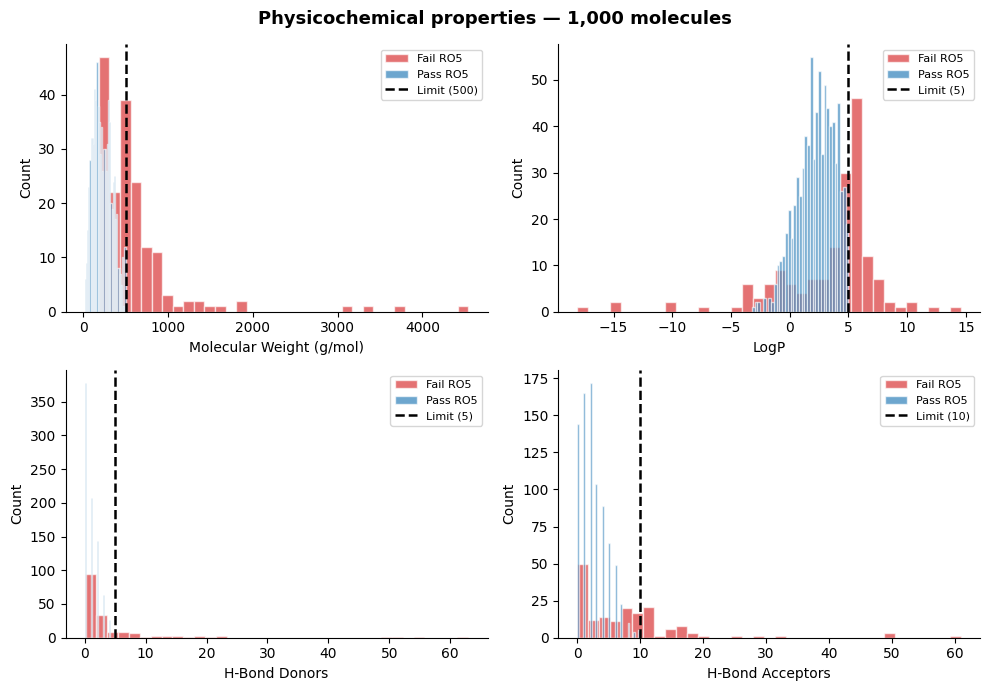

Lipinski pass: 829 / 1000  (82.9%)


In [9]:
from rdkit.Chem import Descriptors
from rdkit.Chem.Crippen import MolLogP
from rdkit.Chem.Lipinski import NumHDonors, NumHAcceptors

df["mol"] = df["smiles"].apply(Chem.MolFromSmiles)
df["MW"] = df["mol"].apply(lambda m: Descriptors.MolWt(m) if m else None)
df["LogP"] = df["mol"].apply(lambda m: MolLogP(m) if m else None)
df["HBD"] = df["mol"].apply(lambda m: NumHDonors(m) if m else None)
df["HBA"] = df["mol"].apply(lambda m: NumHAcceptors(m) if m else None)
df["Lipinski"] = df["mol"].apply(Lipinski)
df_vis = df.dropna(subset=["MW", "LogP", "HBD", "HBA"])

props = [
    ("MW", 500, "Molecular Weight (g/mol)"),
    ("LogP", 5, "LogP"),
    ("HBD", 5, "H-Bond Donors"),
    ("HBA", 10, "H-Bond Acceptors"),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
fig.suptitle(
    "Physicochemical properties — 1,000 molecules", fontsize=13, fontweight="bold"
)

for ax, (col, threshold, xlabel) in zip(axes.flat, props):
    pass_vals = df_vis.loc[df_vis["Lipinski"], col]
    fail_vals = df_vis.loc[~df_vis["Lipinski"], col]
    ax.hist(
        fail_vals,
        bins=35,
        color="#D62728",
        alpha=0.65,
        label="Fail RO5",
        edgecolor="white",
    )
    ax.hist(
        pass_vals,
        bins=35,
        color="#1F77B4",
        alpha=0.65,
        label="Pass RO5",
        edgecolor="white",
    )
    ax.axvline(
        threshold,
        color="black",
        linestyle="--",
        linewidth=1.8,
        label=f"Limit ({threshold})",
    )
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

pass_n = int(df_vis["Lipinski"].sum())
print(f"Lipinski pass: {pass_n} / {len(df_vis)}  ({pass_n/len(df_vis):.1%})")

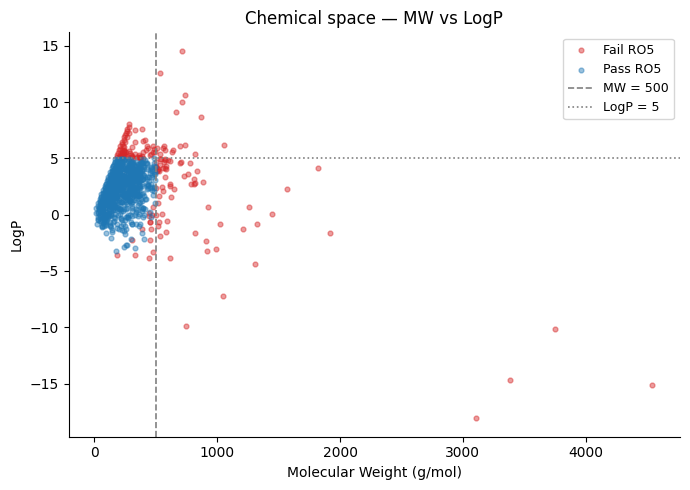

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))

for passes, grp in df_vis.groupby("Lipinski"):
    label = "Pass RO5" if passes else "Fail RO5"
    color = "#1F77B4" if passes else "#D62728"
    ax.scatter(grp["MW"], grp["LogP"], label=label, alpha=0.45, s=12, color=color)

ax.axvline(500, color="gray", linestyle="--", linewidth=1.2, label="MW = 500")
ax.axhline(5, color="gray", linestyle=":", linewidth=1.2, label="LogP = 5")
ax.set_xlabel("Molecular Weight (g/mol)")
ax.set_ylabel("LogP")
ax.set_title("Chemical space — MW vs LogP")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

<a id="s01-smiles"></a>

## 2. SMILES

<div style="padding: 1rem; border-left: 6px solid #4D96FF; background: #F3F8FF; border-radius: 10px;">

**SMILES** stands for **Simplified Molecular Input Line Entry System** [\[2\]](#6.-References).

It is a compact, human-readable text notation that encodes a molecular **graph**, where:

| Graph concept | Molecular meaning | SMILES representation |
|---|---|---|
| **Nodes** | Atoms | `C`, `N`, `O`, `Cl`, `[NH4+]` |
| **Edges** | Bonds | implicit single bonds, `=`, `#` |
| **Branches** | Side chains | `(...)` |
| **Cycles** | Rings | matching digits such as `1...1` |
| **Geometry** | Stereochemistry | `@`, `@@`, `/`, `\` |

</div>


---



### 2.1. Overview

SMILES encodes molecular structure using a small set of compact symbols.

<div style="display: grid; grid-template-columns: repeat(auto-fit, minmax(220px, 1fr)); gap: 0.85rem; align-items: stretch; margin: 1rem 0 0.5rem;">

<div style="padding: 1rem 1.05rem; min-height: 8.2rem; line-height: 1.45; border: 2px solid #2563EB; border-left: 8px solid #1D4ED8; border-radius: 8px; background: #DBEAFE; color: #0F172A; box-shadow: none;">
<b>Atoms</b>

<code>C</code>, <code>N</code>, <code>O</code>, <code>Cl</code>

<p>Atoms are written using element symbols.</p>
</div>

<div style="padding: 1rem 1.05rem; min-height: 8.2rem; line-height: 1.45; border: 2px solid #0F766E; border-left: 8px solid #0F766E; border-radius: 8px; background: #CCFBF1; color: #0F172A; box-shadow: none;">
<b>Bonds</b>

<code>CC</code>, <code>C=C</code>, <code>C#N</code>

<p>Single bonds are usually implicit.</p>
</div>

<div style="padding: 1rem 1.05rem; min-height: 8.2rem; line-height: 1.45; border: 2px solid #B45309; border-left: 8px solid #B45309; border-radius: 8px; background: #FED7AA; color: #0F172A; box-shadow: none;">
<b>Branches</b>

<code>CC(O)C</code>

<p>Parentheses create side chains.</p>
</div>

<div style="padding: 1rem 1.05rem; min-height: 8.2rem; line-height: 1.45; border: 2px solid #7C3AED; border-left: 8px solid #6D28D9; border-radius: 8px; background: #EDE9FE; color: #0F172A; box-shadow: none;">
<b>Rings</b>

<code>C1CCCCC1</code>

<p>Matching digits close rings.</p>
</div>

</div>

<br>

#### Token legend

| Token type | Example | Meaning |
|---|---|---|
| <span style="color:#4D4D4D;"><b>Aliphatic atom</b></span> | `C`, `N`, `O`, `Cl` | Standard non-aromatic atoms |
| <span style="color:#1F77B4;"><b>Aromatic atom</b></span> | `c`, `n`, `o` | Aromatic atoms, usually lowercase |
| <span style="color:#D62728;"><b>Double bond</b></span> | `=` | Explicit double bond |
| <span style="color:#8C564B;"><b>Triple bond</b></span> | `#` | Explicit triple bond |
| <span style="color:#FF7F0E;"><b>Branch</b></span> | `(...)` | Side chain |
| <span style="color:#E377C2;"><b>Ring closure</b></span> | `1`, `2`, `%10` | Connects two atoms to form a ring |
| <span style="color:#9467BD;"><b>Stereochemistry</b></span> | `@`, `@@`, `/`, `\` | Chirality or double-bond geometry |
| <span style="color:#2CA02C;"><b>Bracketed atom</b></span> | `[NH4+]`, `[13C]`, `[O-]` | Explicit hydrogens, isotopes, charges, or uncommon valence |

<div style="padding: 1rem; border-left: 5px solid #999; background: #F7F7F7; border-radius: 8px;">

**Key rule:**  
SMILES is not just a string. It is a compact way to encode a molecular graph.

</div>


---



### 2.2. Atoms & bonds

Atoms are represented by element symbols such as `C`, `N`, `O`, and `Cl`.

Single bonds are usually **implicit**, while double and triple bonds are written explicitly.

| SMILES | Visual interpretation | Meaning |
|---|---|---|
| `C` | C | methane carbon with implicit hydrogens |
| `CCO` | C–C–O | ethanol-like fragment |
| `C=O` | C=O | carbonyl double bond |
| `C#N` | C≡N | triple bond |
| `[Na+]` | Na⁺ | explicit sodium cation |

```text
C      # methane carbon with implicit hydrogens
CCO    # ethanol fragment, C–C–O
C=O    # formaldehyde-like carbonyl
C#N    # hydrogen cyanide or nitrile-like triple bond
[Na+]  # explicit sodium cation
```

<div class="hover-figure caption-hover">
  <img src="../../docs/_static/images/S01/carbonyl.svg" alt="Carbonyl group — C=O double bond">
  <div class="figure-caption">Figure: Carbonyl group — C=O double bond</div>
</div>


### 2.3. Branches

Parentheses create branches or side chains.

```text
CCO       # linear chain
CC(O)C    # branch: hydroxyl on the middle carbon
C(C)(C)C  # tert-butyl-like branching
```
<div class="hover-figure caption-hover">
  <img src="../../docs/_static/images/S01/ethanol.svg" alt="Ethanol — branch notation CC(O)C">
  <div class="figure-caption">Figure: Ethanol — branch notation CC(O)C</div>
</div>


### 2.4. Rings

Ring closures use matching digits to connect two positions in the SMILES string.

```text
C1CCCCC1      # cyclohexane
c1ccccc1      # benzene, aromatic SMILES
C1=CC=CC=C1   # benzene-like Kekulé notation
```
For ring labels above `9`, use `%`.

```text
C%10CCCCCCCCC%10
```

<div class="hover-figure caption-hover">
  <img src="../../docs/_static/images/S01/cyclohexane.svg" alt="Cyclohexane — ring closure C1CCCCC1">
  <div class="figure-caption">Figure: Cyclohexane — ring closure C1CCCCC1</div>
</div>


### 2.5. Aromaticity

Aromatic atoms are commonly written using lowercase letters.

| SMILES | Meaning |
|---|---|
| `c1ccccc1` | benzene |
| `n1ccccc1` | pyridine-like aromatic ring |

```text
c1ccccc1   # benzene, aromatic
n1ccccc1   # pyridine-like aromatic ring
```
<div class="hover-figure caption-hover">
  <img src="../../docs/_static/images/S01/benzene.svg" alt="Benzene — aromatic SMILES c1ccccc1">
  <div class="figure-caption">Figure: Benzene — aromatic SMILES c1ccccc1</div>
</div>


### 2.6. Stereochemistry

SMILES can encode stereochemical information.

| Notation | Used for | Example |
|---|---|---|
| `@` | tetrahedral chirality | <code>C&#91;C@H&#93;(O)Cl</code> |
| `@@` | opposite tetrahedral configuration | <code>C&#91;C@@H&#93;(O)Cl</code> |
| `/` and `\` | double-bond geometry | <code>C/C=C\C</code> |

```text
C&#91;C@H&#93;(O)Cl      # chiral centre with explicit stereochemistry
C/C=C\C          # defined double-bond geometry
```
RDKit preserves stereochemical flags when parsing and writing SMILES with:

```python
Chem.MolToSmiles(mol, isomericSmiles=True)
```

<div class="hover-figure caption-hover">
  <img src="../../docs/_static/images/S01/chiral_example.svg" alt="Chiral centre — tetrahedral stereo C&#91;C@H&#93;(O)Cl">
  <div class="figure-caption">Figure: Chiral centre — tetrahedral stereo C&#91;C@H&#93;(O)Cl</div>
</div>


### 2.7. Bracketed atoms & special cases

Brackets are used when the default SMILES rules are not enough.

Use brackets for:

| Case | Examples |
|---|---|
| explicit hydrogens | `[NH2]`, `[nH]` |
| charges | `[O-]`, `[NH4+]` |
| isotopes | `[13C]` |
| unusual valence states | `[Fe+2]`, `[Se]` |
| explicit atom specification | `[Cl]`, `[Na+]` |

```text
c1ccccc1[NH2]     # aniline with explicit NH2
c1cc[nH]c1        # aromatic nitrogen with explicit H
CC(=O)[O-]        # acetate anion
[NH4+]            # ammonium cation
[NH4+].[Cl-]      # ammonium chloride, ionic pair
[13CH3]C(=O)O     # acetic acid with 13C-labelled methyl carbon
C[Se]C            # dimethyl selenide
```

<div class="hover-figure caption-hover">
  <img src="../../docs/_static/images/S01/acetate.svg" alt="Acetate anion — CC(=O)[O-]">
  <div class="figure-caption">Figure: Acetate anion — CC(=O)[O-]</div>
</div>


### 2.8. Common beginner mistakes

<details>
<summary><b>Click to expand common SMILES mistakes</b></summary>

<br>

| Mistake | Example | Why it matters |
|---|---|---|
| Confusing uppercase and lowercase atoms | `C` vs `c` | `C` is aliphatic, `c` is aromatic |
| Forgetting ring digit pairs | `C1CCCC` | ring closure is incomplete |
| Misplacing branches | `CC(O)C` vs `CCC(O)` | branches attach to the atom before `(` |
| Ignoring stereochemistry | <code>C&#91;C@H&#93;(O)Cl</code> vs <code>CC(O)Cl</code> | stereochemistry may change molecular identity |
| Overusing brackets | `[C][C][O]` | most common atoms do not need brackets |
| Missing charge notation | `[O-]` vs `O` | charged and neutral atoms are different |

</details>


---



### 2.9. Summary

<div style="padding: 1rem; border-left: 6px solid #4D96FF; background: #F3F8FF; border-radius: 10px;">

SMILES is compact because it relies on a small set of rules:

| Feature | Main notation |
|---|---|
| Atoms | `C`, `N`, `O`, `Cl` |
| Aromatic atoms | lowercase, e.g. `c`, `n` |
| Single bonds | usually implicit |
| Double bonds | `=` |
| Triple bonds | `#` |
| Branches | `(...)` |
| Rings | matching digits, e.g. `1...1` |
| Charges/isotopes/explicit H | brackets, e.g. `[NH4+]`, `[13C]` |
| Stereochemistry | `@`, `@@`, `/`, `\` |

</div>

Now experiment with some examples

The cell below color-codes each SMILES token by its syntactic role — useful for parsing unfamiliar strings.
Each color corresponds to a token class (aromatic atom, branch, ring closure, stereo, etc.).

In [11]:

import re
import html
from collections import Counter
from IPython.display import HTML, display


_TOKEN_PATTERNS = [
    (r"\[[^\]]+\]", "Bracketed atom / group", "#2CA02C", "#EAF7EA"),
    (r"%\d{2}|\d", "Ring closure", "#E377C2", "#FCEAF7"),
    (r"[cnops]", "Aromatic atom", "#1F77B4", "#EAF2FB"),
    (r"[A-Z][a-z]?", "Aliphatic atom", "#4D4D4D", "#F0F0F0"),
    (r"=", "Double bond", "#D62728", "#FDECEC"),
    (r"#", "Triple bond", "#8C564B", "#F3ECE9"),
    (r"-", "Single bond", "#7F7F7F", "#F2F2F2"),
    (r"[()]", "Branch", "#FF7F0E", "#FFF1E5"),
    (r"[@/\\]", "Stereo", "#9467BD", "#F3ECFA"),
    (r"\.", "Disconnected component", "#17BECF", "#E7F9FB"),
]


def tokenize_smiles(smiles: str):
    tokens = []
    i = 0

    while i < len(smiles):
        remaining = smiles[i:]

        for pattern, label, color, bg in _TOKEN_PATTERNS:
            m = re.match(pattern, remaining)
            if m:
                tok = m.group(0)
                tokens.append(
                    {
                        "text": tok,
                        "label": label,
                        "color": color,
                        "bg": bg,
                        "start": i,
                        "end": i + len(tok) - 1,
                    }
                )
                i += len(tok)
                break
        else:
            tokens.append(
                {
                    "text": remaining[0],
                    "label": "Other",
                    "color": "#111111",
                    "bg": "#FFFFFF",
                    "start": i,
                    "end": i,
                }
            )
            i += 1

    return tokens


def annotate_smiles_html(
    smiles: str, title: str | None = None, show_indices: bool = True
) -> str:
    tokens = tokenize_smiles(smiles)
    counts = Counter(t["label"] for t in tokens)

    token_html = ""
    index_html = ""

    for t in tokens:
        safe_tok = html.escape(t["text"])

        token_html += f"""
        <span class="smi-token"
              title="{html.escape(t['label'])}: position {t['start']}"
              style="
                color:{t['color']};
                background:{t['bg']};
                border:1px solid {t['color']}55;
              ">
            {safe_tok}
        </span>
        """

        if show_indices:
            idx = str(t["start"]) if len(t["text"]) == 1 else f"{t['start']}-{t['end']}"
            index_html += f"""
            <span class="smi-index">{idx}</span>
            """

    legend_items = []
    seen = {}

    for t in tokens:
        if t["label"] not in seen:
            seen[t["label"]] = (t["color"], t["bg"])

    for label, (color, bg) in seen.items():
        legend_items.append(
            f"""
            <span class="smi-legend-item" style="background:{bg};border-color:{color}55">
                <span style="color:{color};font-weight:800">■</span>
                {html.escape(label)}
                <span class="smi-count">{counts[label]}</span>
            </span>
            """
        )

    title_html = ""
    if title:
        title_html = f"""
        <div class="smi-title">
            {html.escape(title)}
        </div>
        """

    return f"""
    <style>
        .smi-card {{
            font-family: Inter, system-ui, -apple-system, BlinkMacSystemFont, "Segoe UI", sans-serif;
            border: 1px solid #E5E7EB;
            border-radius: 14px;
            padding: 14px 16px;
            margin: 12px 0;
            background: linear-gradient(180deg, #FFFFFF 0%, #FAFAFA 100%);
            box-shadow: 0 4px 14px rgba(0,0,0,0.06);
            max-width: 920px;
        }}

        .smi-title {{
            font-weight: 750;
            font-size: 15px;
            margin-bottom: 8px;
            color: #111827;
        }}

        .smi-raw {{
            font-family: ui-monospace, SFMono-Regular, Menlo, Consolas, monospace;
            font-size: 12px;
            color: #6B7280;
            margin-bottom: 10px;
            word-break: break-all;
        }}

        .smi-token-row {{
            display: flex;
            flex-wrap: wrap;
            gap: 5px;
            align-items: center;
            margin-bottom: 6px;
        }}

        .smi-token {{
            font-family: ui-monospace, SFMono-Regular, Menlo, Consolas, monospace;
            font-weight: 800;
            font-size: 18px;
            line-height: 1.2;
            padding: 5px 7px;
            border-radius: 8px;
            display: inline-block;
            transition: transform 0.12s ease, box-shadow 0.12s ease;
        }}

        .smi-token:hover {{
            transform: translateY(-2px) scale(1.05);
            box-shadow: 0 4px 10px rgba(0,0,0,0.12);
            cursor: help;
        }}

        .smi-index-row {{
            display: flex;
            flex-wrap: wrap;
            gap: 5px;
            margin-bottom: 12px;
        }}

        .smi-index {{
            font-family: ui-monospace, SFMono-Regular, Menlo, Consolas, monospace;
            color: #9CA3AF;
            background: #F9FAFB;
            border: 1px solid #E5E7EB;
            border-radius: 6px;
            padding: 2px 6px;
            font-size: 10px;
            min-width: 18px;
            text-align: center;
        }}

        .smi-legend {{
            display: flex;
            flex-wrap: wrap;
            gap: 7px;
            margin-top: 10px;
        }}

        .smi-legend-item {{
            border: 1px solid;
            border-radius: 999px;
            padding: 4px 9px;
            font-size: 12px;
            color: #374151;
            display: inline-flex;
            align-items: center;
            gap: 5px;
        }}

        .smi-count {{
            color: #6B7280;
            background: #FFFFFFAA;
            border-radius: 999px;
            padding: 1px 6px;
            font-size: 11px;
            font-weight: 700;
        }}
    </style>

    <div class="smi-card">
        {title_html}

        <div class="smi-raw">
            Raw SMILES: {html.escape(smiles)}
        </div>

        <div class="smi-token-row">
            {token_html}
        </div>

        {f'<div class="smi-index-row">{index_html}</div>' if show_indices else ''}

        <div class="smi-legend">
            {''.join(legend_items)}
        </div>
    </div>
    """


examples = [
    ("Aspirin", "CC(=O)Oc1ccccc1C(=O)O"),
    ("Chiral", "C[C@H](O)Cl"),
    ("Pyrrole", "c1cc[nH]c1"),
    ("Ionic pair", "[Na+].[Cl-]"),
    ("Nitrile", "C#N"),
]

for name, smi in examples:
    display(HTML(annotate_smiles_html(smi, title=name)))

SMILES strings can have many valid variants for the same molecule [\[5\]](#6.-References).


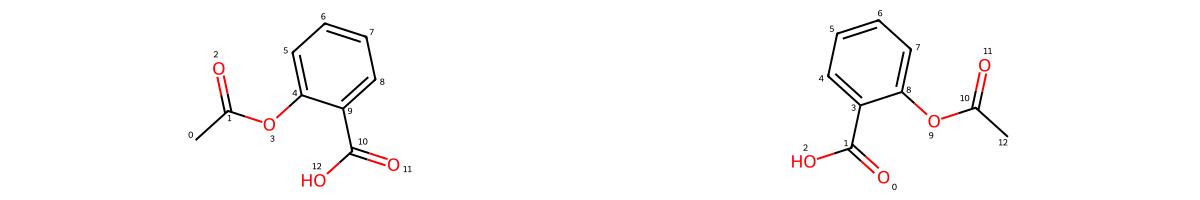

In [12]:
from rdkit.Chem import Draw

s1 = "CC(=O)Oc1ccccc1C(=O)O"
s2 = "O=C(O)c1ccccc1OC(=O)C"

m1 = Chem.MolFromSmiles(s1)
m2 = Chem.MolFromSmiles(s2)

Draw.MolsToGridImage([m1, m2], molsPerRow=2, subImgSize=(600, 200))

The
simplest and most reliable way to compare or normalise SMILES is to convert
them to a **canonical form** in RDKit [\[1\]](#6.-References), [\[5\]](#6.-References), [\[6\]](#6.-References).


canonical 1: CC(=O)Oc1ccccc1C(=O)O
canonical 2: CC(=O)Oc1ccccc1C(=O)O
same SMILES? True


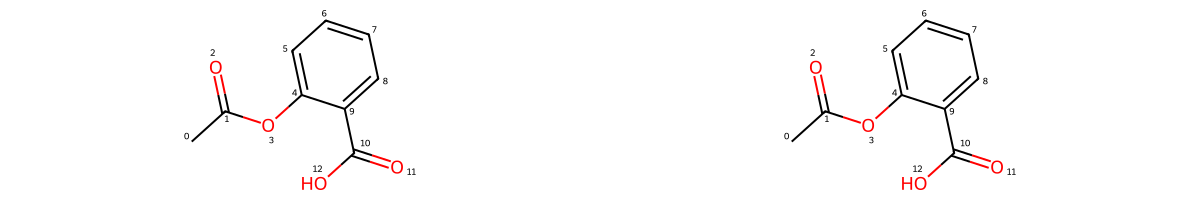

In [13]:
can1 = Chem.CanonSmiles(s1)
can2 = Chem.CanonSmiles(s2)
print("canonical 1:", can1)
print("canonical 2:", can2)
print("same SMILES?", can1 == can2)

m1 = Chem.MolFromSmiles(can1)
m2 = Chem.MolFromSmiles(can2)

Draw.MolsToGridImage([m1, m2], molsPerRow=2, subImgSize=(600, 200))

Graph canonicalization (canonical SMILES, toolkit differences) will be covered in later talktorials (**S06**).


<a id="s01-graph"></a>

## 3. Molecular Graph representation

In computational reaction modeling, we represent molecules as **labeled graphs** so that any notion of
“matching” respects **chemical identity**, such as element type, charge, and bond order, rather than bare
connectivity alone [\[4\]](#6.-References).

A **labeled molecular graph** is a quadruple

$$
G = (V, E, a, b),
$$

where:

- **Vertices** $V$ represent **atoms**.
- **Edges** $E \subseteq \{\{u,v\}\mid u,v\in V,\ u\neq v\}$ represent **bonds**
  (finite, undirected, simple: no loops, no parallel edges).
- $a$: atom labelling function.
- $b$: bond labelling function.

We often write $V(G)$ and $E(G)$ for the vertex and edge sets of $G$. For a vertex $v\in V(G)$:

- neighbourhood:
  $$
  N_G(v)=\{w\in V(G)\mid vw\in E(G)\},
  $$
- degree:
  $$
  \deg_G(v)=|N_G(v)|.
  $$

These graph-theoretic notions correspond chemically to an atom’s bonded neighbours and coordination number,
abstracting away geometry while retaining connectivity.

---

### 3.1. Labels and chemical types

Attributes are encoded via explicit labelling maps

$$
\ell_V: V(G)\to L_V,\qquad \ell_E: E(G)\to L_E,
$$

where $L_V$ and $L_E$ are finite, non-empty label sets.
For molecular graphs, we use the chemistry-specific notation:

$$
a_G: V(G)\to L_V \quad\text{(atom labels)},\qquad
b_G: E(G)\to L_E \quad\text{(bond labels)}.
$$

Let $\mathcal{G}$ denote the class of all labelled molecular graphs equipped with $(a_G,b_G)$.
In chemistry, $a_G(v)$ encodes *what atom this is* (element, charge, aromaticity, hydrogen count, …), 
while $b_G(uv)$ encodes *what bond this is* (order, aromaticity, ring status, …).

All subsequent notions of equivalence, symmetry, and matching in this talktorial are defined **relative to these labels**.

---

### 3.2. Graph representations in practice

In SynEdu, **RDKit** and **NetworkX** play complementary roles:

- **RDKit** is the chemical authority: sanitization, valence rules, aromaticity perception, and canonicalization.
- **NetworkX** provides an explicit, inspectable graph representation used for matching, symmetry analysis,
  and later graph rewriting.

To ensure that graph-based operations remain chemically meaningful, we require a **reversible interface**
between the two representations:
a molecule converted from RDKit to a labeled NetworkX graph must be convertible back without loss of
the chemical information encoded in $(a_G,b_G)$.

This reversible interface forms the foundation for all later notions—graph isomorphism, automorphisms,
and eventually reaction rules—introduced in subsequent SynEdu notebooks.


**Definition (Labeled Molecular Graph).**  
A *labeled molecular graph* is a 4-tuple

$$
G = (V,\, E,\, \mathbf{a},\, \mathbf{b})
$$

where $V$ is the set of **heavy atoms** (nodes), $E \subseteq \{\{u,v\}\mid u,v\in V,\ u\neq v\}$ is the set of **covalent bonds** (undirected edges), $\mathbf{a}: V \to \mathcal{A}$ assigns each atom a tuple of **node attributes** (element symbol, formal charge, aromaticity, hydrogen count, atom-map number), and $\mathbf{b}: E \to \mathcal{B}$ assigns each bond a tuple of **edge attributes** (bond order, aromaticity).

A *labeled graph morphism* $\varphi: G_1 \to G_2$ is a pair of maps $\varphi_V: V_1 \to V_2$, $\varphi_E: E_1 \to E_2$ that (i) preserves adjacency: $\varphi_E(\{u,v\}) = \{\varphi_V(u), \varphi_V(v)\}$, and (ii) preserves labels: $\mathbf{a}_2(\varphi_V(v)) = \mathbf{a}_1(v)$ and $\mathbf{b}_2(\varphi_E(e)) = \mathbf{b}_1(e)$ for all $v \in V_1$, $e \in E_1$.

**Remark.** The attribute schema used throughout SynEdu is  
`a(v) = (element, formal_charge, aromatic, hcount, atom_map)` and `b(e) = (order, aromatic)`.  
Hydrogen atoms are stored implicitly in `hcount` to keep graphs small.


In [14]:
from typing import Dict, Any
import networkx as nx
from rdkit import Chem

In [15]:
def mol_to_graph(
    mol: Chem.Mol,
    drop_non_aam: bool = False,
    use_index_as_atom_map: bool = False,
) -> nx.Graph:
    """
    Convert an RDKit Mol to a lightweight heavy-atom NetworkX graph.

    :param mol: RDKit molecule.
    :type mol: rdkit.Chem.Mol
    :param drop_non_aam: If True, skip atoms that carry no atom-map number.
    :type drop_non_aam: bool
    :param use_index_as_atom_map: If True, use atom index as node ID and set
        ``atom_map`` attribute to the index. If False, use atom-map number
        when present, falling back to a unique atom index.
    :type use_index_as_atom_map: bool
    :returns: Graph with element/formal_charge/aromatic/hcount/atom_map node
        attributes and order/aromatic edge attributes.
    :rtype: networkx.Graph
    """
    G: nx.Graph = nx.Graph()
    local: Dict[int, Any] = {}

    # Existing atom-map numbers, used to avoid collisions with fallback IDs
    used_aam = {
        atom.GetAtomMapNum() for atom in mol.GetAtoms() if atom.GetAtomMapNum() > 0
    }

    next_fallback_id = 1

    def get_unique_fallback_id() -> int:
        nonlocal next_fallback_id
        while next_fallback_id in used_aam:
            next_fallback_id += 1
        out = next_fallback_id
        used_aam.add(out)
        next_fallback_id += 1
        return out

    for atom in mol.GetAtoms():
        atom_idx = atom.GetIdx()
        am = int(atom.GetAtomMapNum())

        if drop_non_aam and am == 0:
            continue

        if use_index_as_atom_map:
            node_id = atom_idx + 1
            node_am = atom_idx + 1
        elif am > 0:
            node_id = am
            node_am = am
        else:
            node_id = get_unique_fallback_id()
            node_am = 0

        local[atom_idx] = node_id

        G.add_node(
            node_id,
            element=atom.GetSymbol(),
            formal_charge=int(atom.GetFormalCharge()),
            aromatic=bool(atom.GetIsAromatic()),
            hcount=int(atom.GetTotalNumHs()),
            atom_map=node_am,
        )

    for bond in mol.GetBonds():
        u = local.get(bond.GetBeginAtomIdx())
        v = local.get(bond.GetEndAtomIdx())

        if u is None or v is None:
            continue

        G.add_edge(
            u,
            v,
            order=float(bond.GetBondTypeAsDouble()),
            aromatic=bool(bond.GetIsAromatic()),
        )

    return G

#### Graph attribute inspection

The DataFrames below show the concrete realization of the label functions $a_G$ (node attributes) and $b_G$ (edge attributes) for phenol.
This makes explicit what information is stored — and therefore what is available for downstream matching and rewriting.

In [16]:
mol_ex = Chem.MolFromSmiles(Chem.CanonSmiles("c1ccccc1O"))  # phenol
G_ex = mol_to_graph(mol_ex)

node_df = pd.DataFrame(
    [{"node_id": n, **d} for n, d in sorted(G_ex.nodes(data=True))]
).set_index("node_id")

edge_df = pd.DataFrame([{"u": u, "v": v, **d} for u, v, d in G_ex.edges(data=True)])

print("Node attributes  (a_G — atom labels) — phenol:")
display(node_df)
print("\nEdge attributes  (b_G — bond labels) — phenol:")
display(edge_df)

Node attributes  (a_G — atom labels) — phenol:


,element,formal_charge,aromatic,hcount,atom_map
node_id,,,,,
1,O,0,False,1,0
2,C,0,True,0,0
3,C,0,True,1,0
4,C,0,True,1,0
5,C,0,True,1,0
6,C,0,True,1,0
7,C,0,True,1,0



Edge attributes  (b_G — bond labels) — phenol:


,u,v,order,aromatic
0,1,2,1.0,False
1,2,3,1.5,True
2,2,7,1.5,True
3,3,4,1.5,True
4,4,5,1.5,True
5,5,6,1.5,True
6,6,7,1.5,True


In [17]:
def graph_to_mol(
    G: nx.Graph,
    sanitize: bool = True,
    use_h_count: bool = False,
    use_atom_map: bool = True,
    preserve_aromatic: bool = True,
) -> Chem.Mol:
    """
    Reconstruct an RDKit Mol from a NetworkX graph.

    Supports:
    - element
    - formal_charge
    - atom_map
    - bond order
    - aromatic bonds
    - optional explicit H count
    """
    rw = Chem.RWMol()
    node_to_idx: Dict[Any, int] = {}

    for node, data in G.nodes(data=True):
        element = data.get("element", "C")
        charge = int(data.get("formal_charge", 0))

        atom = Chem.Atom(element)
        atom.SetFormalCharge(charge)

        if use_atom_map:
            am = int(data.get("atom_map", 0) or 0)
            if am:
                atom.SetAtomMapNum(am)

        atom.SetIsAromatic(False)

        idx = rw.AddAtom(atom)
        node_to_idx[node] = idx

    for u, v, data in G.edges(data=True):
        i = node_to_idx[u]
        j = node_to_idx[v]

        if preserve_aromatic and bool(data.get("aromatic", False)):
            btype = Chem.BondType.AROMATIC
        else:
            try:
                order = int(round(abs(float(data.get("order", 1.0)))))
            except Exception:
                order = 1

            btype = {
                1: Chem.BondType.SINGLE,
                2: Chem.BondType.DOUBLE,
                3: Chem.BondType.TRIPLE,
            }.get(order, Chem.BondType.SINGLE)

        rw.AddBond(i, j, btype)

    if use_h_count:
        for node, data in G.nodes(data=True):
            try:
                n_h = int(data.get("hcount", 0))
            except Exception:
                continue

            if n_h <= 0:
                continue

            atom = rw.GetAtomWithIdx(node_to_idx[node])
            atom.SetNoImplicit(True)
            atom.SetNumExplicitHs(n_h)

    mol = rw.GetMol()

    if sanitize:
        Chem.SanitizeMol(
            mol,
            sanitizeOps=Chem.SanitizeFlags.SANITIZE_ALL
            ^ Chem.SanitizeFlags.SANITIZE_SETAROMATICITY
            ^ Chem.SanitizeFlags.SANITIZE_KEKULIZE,
        )
        Chem.SetAromaticity(mol)

    return mol

> **Stored in `synedu.Utils`** — both `mol_to_graph` and `graph_to_mol` (defined above) are packaged in `synedu.Utils.conversion` so every later talktorial can import them without redefining them:
> ```python
> from synedu.Utils.conversion import mol_to_graph, graph_to_mol
> ```
> `smiles_to_graph` and `graph_to_smi` (thin wrappers around these) are available there too.

Is consistent: True


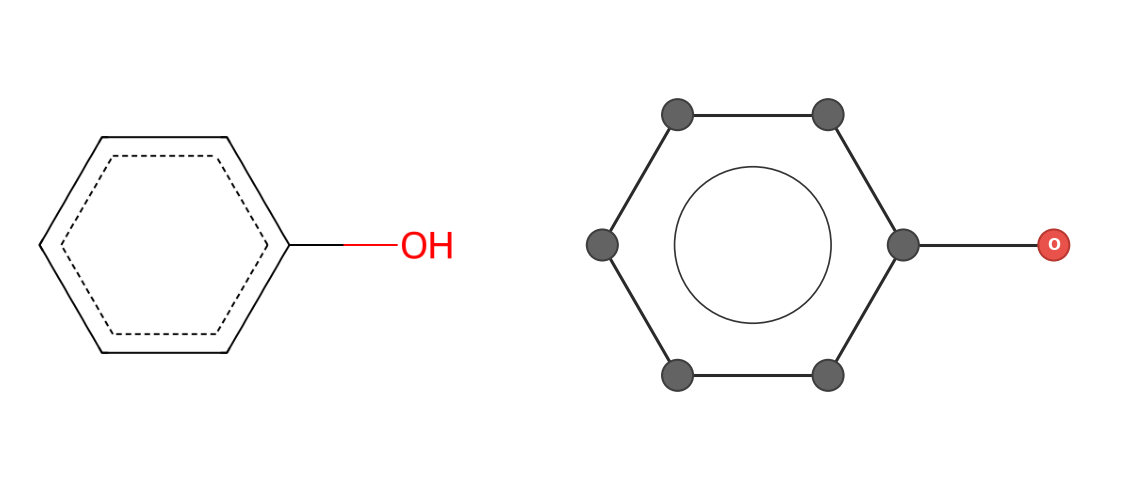

In [18]:
s = Chem.CanonSmiles("c1ccccc1O")
m = Chem.MolFromSmiles(s)
G = mol_to_graph(m)
m1 = graph_to_mol(G)
s1 = Chem.MolToSmiles(m1, canonical=True)
print("Is consistent:", s == s1)

draw_molecular_graph(G, include_mol=True, label_mode="hetero", aromatic_style="circle")
plt.show()

#### Kekulé vs aromatic — graph label differences

The same molecule (benzene) written in two SMILES notations produces **different bond-order labels** in the graph:
- **Kekulé** (`C1=CC=CC=C1`): alternating single (1.0) and double (2.0) bonds.
- **Aromatic** (`c1ccccc1`): uniform aromatic bonds (order 1.5), with an `aromatic=True` flag on all nodes and edges.

This distinction matters for graph isomorphism and reaction rule matching in later notebooks.

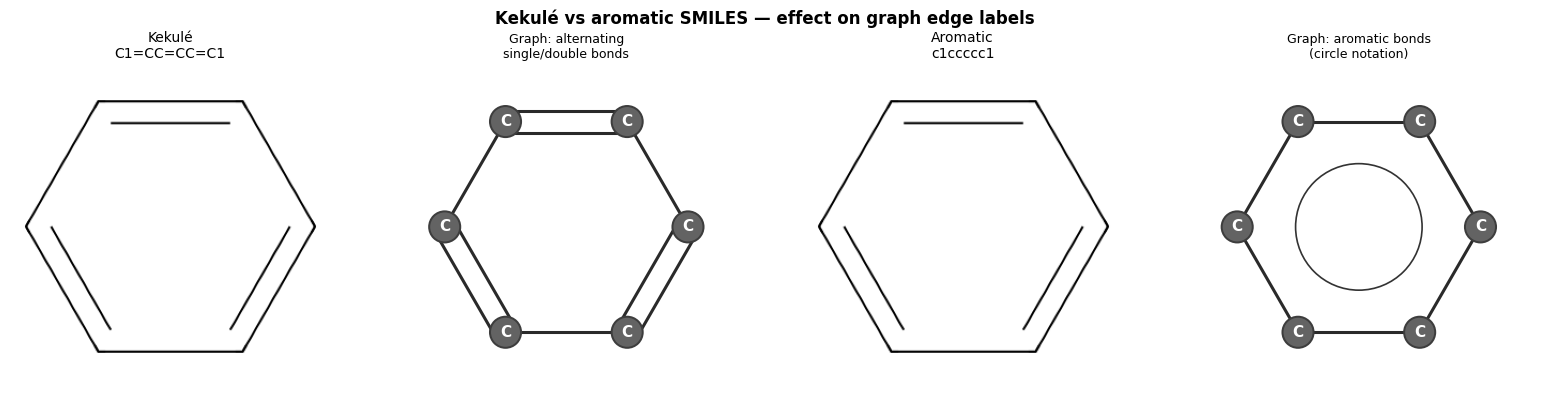

Kekulé  bond orders:  [1.0, 2.0]
Aromatic bond orders: [1.5]
Aromatic node flags:  [True]


In [19]:
from rdkit.Chem import Draw

kekule_smi = "C1=CC=CC=C1"  # Kekulé benzene
aromatic_smi = "c1ccccc1"  # aromatic benzene

mol_kek = Chem.MolFromSmiles(kekule_smi)
Chem.Kekulize(
    mol_kek, clearAromaticFlags=True
)  # forces alternating 1/2 bonds, clears aromatic flags

mol_arom = Chem.MolFromSmiles(aromatic_smi)
G_kek = mol_to_graph(mol_kek)
G_arom = mol_to_graph(mol_arom)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle(
    "Kekulé vs aromatic SMILES — effect on graph edge labels",
    fontsize=12,
    fontweight="bold",
)

for col, mol, G, title_mol, title_g in [
    (
        0,
        mol_kek,
        G_kek,
        f"Kekulé\n{kekule_smi}",
        "Graph: alternating\nsingle/double bonds",
    ),
    (
        2,
        mol_arom,
        G_arom,
        f"Aromatic\n{aromatic_smi}",
        "Graph: aromatic bonds\n(circle notation)",
    ),
]:
    axes[col].imshow(Draw.MolToImage(mol, size=(300, 300)))
    axes[col].set_title(title_mol, fontsize=10)
    axes[col].axis("off")
    draw_molecular_graph(G, ax=axes[col + 1], label_mode="all", aromatic_style="circle")
    axes[col + 1].set_title(title_g, fontsize=9)

plt.tight_layout()
plt.show()

print(
    "Kekulé  bond orders: ",
    sorted(set(d["order"] for _, _, d in G_kek.edges(data=True))),
)
print(
    "Aromatic bond orders:",
    sorted(set(d["order"] for _, _, d in G_arom.edges(data=True))),
)
print(
    "Aromatic node flags: ",
    sorted(set(d["aromatic"] for _, d in G_arom.nodes(data=True))),
)

### 3.3. Matrix representations

A labeled molecular graph can be encoded as several **matrices**, each capturing a different structural aspect [\[4\]](#6.-References), [\[7\]](#6.-References), [\[8\]](#6.-References):

| Matrix | Shape | Entry meaning |
|---|---|---|
| **Adjacency** $A$ | $n \times n$ | $A_{ij}$ = bond order between atoms $i$ and $j$ |
| **Distance** $D$ | $n \times n$ | $D_{ij}$ = shortest-path length (in bonds) between $i$ and $j$ |
| **Incidence** $B$ | $n \times m$ | $B_{ij} = 1$ if atom $i$ participates in bond $j$ |
| **Bond-Electron** $BE$ | $n \times n$ | off-diag = bond order; **diagonal = free (non-bonding) electrons** |

The BE matrix generalises the adjacency matrix by placing lone-pair electron counts on the diagonal.
For a reaction, the **difference** $\Delta BE = BE_\text{products} - BE_\text{reactants}$ encodes the full electron reorganisation — this is developed in **S04**.

#### Adjacency

The **adjacency matrix** $A \in \mathbb{R}^{n \times n}$ encodes pairwise atom connectivity.
Three variants are informative:

| Panel | Entry $A_{ij}$ | When useful |
|---|---|---|
| **Binary** | 1 if bond exists, else 0 | Connectivity-only algorithms (BFS, diameter) |
| **Weighted — aromatic** | Bond order from aromatic SMILES (1.5 for ring bonds) | Aromatic-aware descriptors |
| **Weighted — Kekulé** | Bond order from Kekulé SMILES (1.0 or 2.0) | Reaction-rule matching, BE matrix |

Key properties shared by all variants:
- **Symmetric**: $A_{ij} = A_{ji}$ (undirected bonds)
- **Zero diagonal**: no self-loops ($A_{ii} = 0$)
- Diagonal entries of the degree matrix $\mathrm{Deg}$ give the heavy-atom degree of each atom

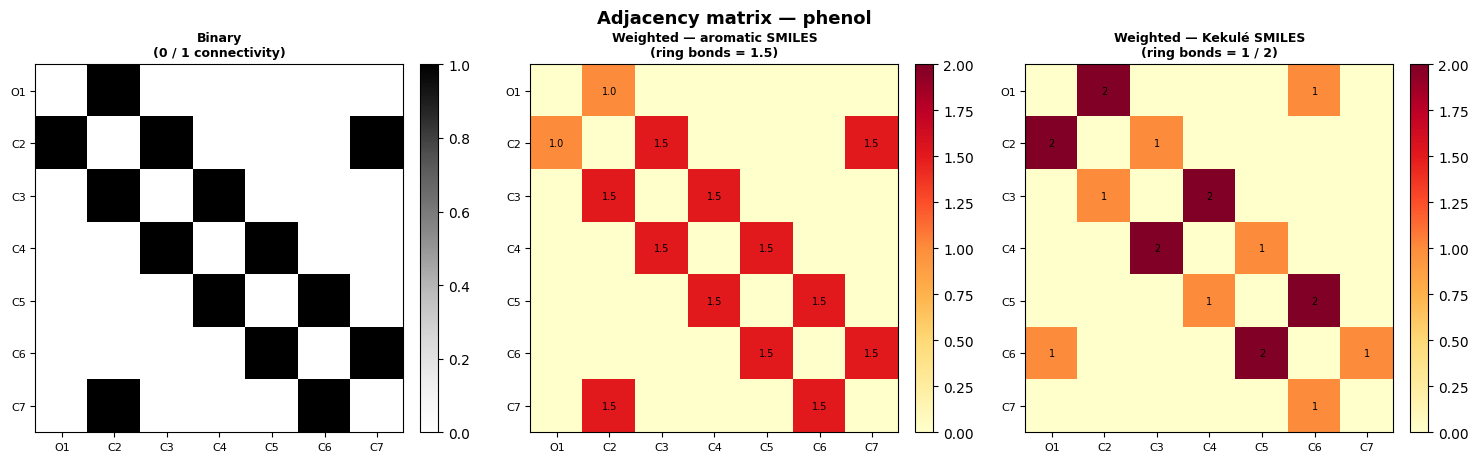

Aromatic ring bond orders: [1.0, 1.5]
Kekulé  ring bond orders:  [1.0, 2.0]


In [20]:
import numpy as np

# Aromatic form: ring bonds have order 1.5
mol_arom = Chem.MolFromSmiles(Chem.CanonSmiles("c1ccccc1O"))

# Kekulé form: ring bonds alternate 1.0 / 2.0
mol_kek = Chem.RWMol(Chem.MolFromSmiles("c1ccccc1O"))
Chem.Kekulize(mol_kek, clearAromaticFlags=True)

G_arom = mol_to_graph(mol_arom)
G_kek = mol_to_graph(mol_kek)

ordered = sorted(G_arom.nodes())
tick = [f"{G_arom.nodes[n]['element']}{n}" for n in ordered]

A_bin = (
    nx.to_numpy_array(G_arom, nodelist=ordered, weight="order", nonedge=0.0) > 0
).astype(float)
A_arom = nx.to_numpy_array(G_arom, nodelist=ordered, weight="order", nonedge=0.0)
A_kek = nx.to_numpy_array(G_kek, nodelist=ordered, weight="order", nonedge=0.0)


def _adj_panel(ax, A, tick, title, cmap, vmax, fmt_fn):
    im = ax.imshow(A, cmap=cmap, vmin=0, vmax=vmax)
    n = len(tick)
    ax.set_xticks(range(n))
    ax.set_xticklabels(tick, fontsize=8)
    ax.set_yticks(range(n))
    ax.set_yticklabels(tick, fontsize=8)
    for i in range(n):
        for j in range(n):
            if A[i, j] > 0:
                ax.text(
                    j,
                    i,
                    fmt_fn(A[i, j]),
                    ha="center",
                    va="center",
                    fontsize=7,
                    color="black",
                )
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=9, fontweight="bold", pad=6)


fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle("Adjacency matrix — phenol", fontsize=13, fontweight="bold")

_adj_panel(
    axes[0], A_bin, tick, "Binary\n(0 / 1 connectivity)", "Greys", 1, lambda v: "1"
)
_adj_panel(
    axes[1],
    A_arom,
    tick,
    "Weighted — aromatic SMILES\n(ring bonds = 1.5)",
    "YlOrRd",
    2,
    lambda v: f"{v:.1f}",
)
_adj_panel(
    axes[2],
    A_kek,
    tick,
    "Weighted — Kekulé SMILES\n(ring bonds = 1 / 2)",
    "YlOrRd",
    2,
    lambda v: f"{v:.0f}",
)

plt.tight_layout()
plt.show()

print(
    "Aromatic ring bond orders:",
    sorted(set(d["order"] for _, _, d in G_arom.edges(data=True))),
)
print(
    "Kekulé  ring bond orders: ",
    sorted(set(d["order"] for _, _, d in G_kek.edges(data=True))),
)

#### Distance matrix

The **topological distance matrix** $D \in \mathbb{N}^{n \times n}$ records the
shortest-path length (measured in bonds) between every pair of atoms.
$D_{ij}$ is the minimum number of bonds to traverse to reach atom $j$ from atom $i$,
computed via Floyd–Warshall or breadth-first search on the unweighted graph.

Key properties:
- **Zero diagonal**: $D_{ii} = 0$
- **Symmetric**: $D_{ij} = D_{ji}$
- The **graph diameter** $\max_{i,j} D_{ij}$ is the longest shortest path — a
  compact measure of molecular "stretch"
- Distance-based **Wiener index** $W = \tfrac{1}{2}\sum_{i,j} D_{ij}$ correlates
  with boiling points for alkanes [\[7\]](#6.-References)

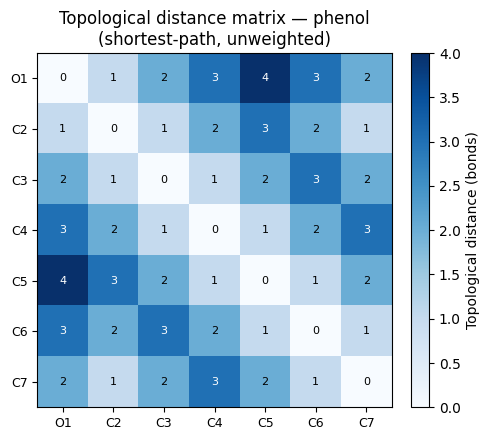

Graph diameter (eccentricity max): 4 bonds


In [21]:
import numpy as np

mol_dist = Chem.MolFromSmiles(Chem.CanonSmiles("c1ccccc1O"))  # phenol
G_dist = mol_to_graph(mol_dist)

ordered_dist = sorted(G_dist.nodes())
tick_dist = [f"{G_dist.nodes[n]['element']}{n}" for n in ordered_dist]
D = nx.floyd_warshall_numpy(G_dist, nodelist=ordered_dist)

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(D, cmap="Blues")
ax.set_xticks(range(len(tick_dist)))
ax.set_xticklabels(tick_dist, fontsize=9)
ax.set_yticks(range(len(tick_dist)))
ax.set_yticklabels(tick_dist, fontsize=9)

for i in range(len(ordered_dist)):
    for j in range(len(ordered_dist)):
        ax.text(
            j,
            i,
            int(D[i, j]),
            ha="center",
            va="center",
            fontsize=8,
            color="white" if D[i, j] > 2.5 else "black",
        )

plt.colorbar(im, ax=ax, fraction=0.046, label="Topological distance (bonds)")
ax.set_title("Topological distance matrix — phenol\n(shortest-path, unweighted)")
plt.tight_layout()
plt.show()

# diameter = longest shortest path in the molecule
print(f"Graph diameter (eccentricity max): {int(D.max())} bonds")

#### Incidence matrix

The **node-edge incidence matrix** $B \in \{0,1\}^{n \times m}$ maps atoms to bonds:
$B_{ij} = 1$ if atom $i$ participates in bond $j$, and 0 otherwise.

Key properties:
- Each **column** has exactly two 1s (every bond connects exactly two atoms)
- Each **row sum** equals the heavy-atom degree (valence) of that atom
- $B B^\top = \mathrm{Deg} + A_{\mathrm{bin}}$, where $\mathrm{Deg}$ is the diagonal degree matrix and $A_{\mathrm{bin}}$ is
  the binary adjacency matrix — a fundamental identity in algebraic graph theory
- Incidence matrices appear in spectral graph theory and in the cycle-space
  formulation of Kirchhoff's current laws

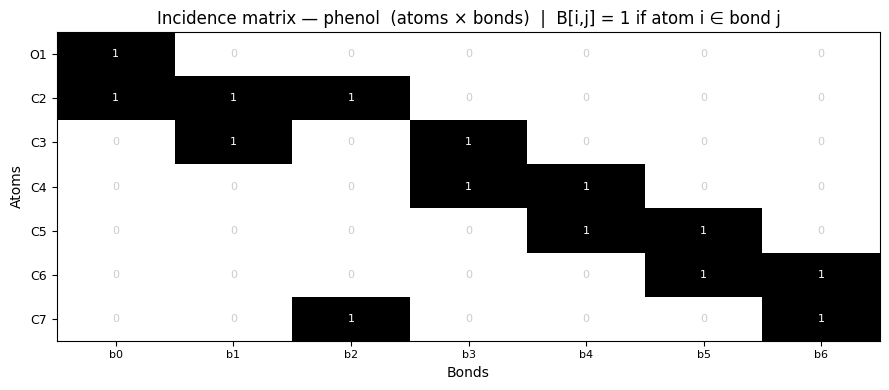

Matrix shape: 7 atoms × 7 bonds
Row sums (valency in heavy-atom graph): {'O1': 1, 'C2': 3, 'C3': 2, 'C4': 2, 'C5': 2, 'C6': 2, 'C7': 2}


In [22]:
import numpy as np

mol_inc = Chem.MolFromSmiles(Chem.CanonSmiles("c1ccccc1O"))  # phenol
G_inc = mol_to_graph(mol_inc)

ordered_nodes = sorted(G_inc.nodes())
ordered_edges = list(G_inc.edges())
n_atoms = len(ordered_nodes)
n_bonds = len(ordered_edges)
atom_idx = {node: i for i, node in enumerate(ordered_nodes)}

B_inc = np.zeros((n_atoms, n_bonds), dtype=int)
for j, (u, v) in enumerate(ordered_edges):
    B_inc[atom_idx[u], j] = 1
    B_inc[atom_idx[v], j] = 1

atom_labels = [f"{G_inc.nodes[n]['element']}{n}" for n in ordered_nodes]
bond_labels = [f"b{j}" for j in range(n_bonds)]

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(B_inc, cmap="Greys", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(n_bonds))
ax.set_xticklabels(bond_labels, fontsize=8)
ax.set_yticks(range(n_atoms))
ax.set_yticklabels(atom_labels, fontsize=9)
ax.set_xlabel("Bonds")
ax.set_ylabel("Atoms")

for i in range(n_atoms):
    for j in range(n_bonds):
        ax.text(
            j,
            i,
            B_inc[i, j],
            ha="center",
            va="center",
            fontsize=8,
            color="white" if B_inc[i, j] else "#cccccc",
        )

ax.set_title(
    "Incidence matrix — phenol  (atoms × bonds)  |  B[i,j] = 1 if atom i ∈ bond j"
)
plt.tight_layout()
plt.show()

print(f"Matrix shape: {n_atoms} atoms × {n_bonds} bonds")
print(
    f"Row sums (valency in heavy-atom graph): { {atom_labels[i]: int(B_inc[i].sum()) for i in range(n_atoms)} }"
)

#### Bond-electron matrix

The **Bond-Electron (BE) matrix** $M \in \mathbb{R}^{n \times n}$ extends the
weighted adjacency matrix by encoding electron counts on the diagonal [\[8\]](#6.-References):

$$
M_{ij} = \begin{cases}
  b_{ij} & i \neq j \quad (\text{bond order between atoms } i \text{ and } j) \\
  v_i - q_i - \displaystyle\sum_j b_{ij} - h_i & i = j \quad (\text{free / non-bonding electrons on atom } i)
\end{cases}
$$

where $v_i$ is the valence electron count, $q_i$ the formal charge, and $h_i$ the
implicit hydrogen count.

**Aromatic vs Kekulé** — two panels below highlight a key practical concern:
- In the **aromatic** form, ring bond orders are 1.5, giving fractional diagonal values
  that have no physical meaning.
- In the **Kekulé** form, all bond orders are integers, and the diagonal is a
  well-defined electron count.

For this reason, reaction-informatics tools always work with the **Kekulé BE matrix**.
The reaction-level version — the **ΔBE matrix** — is developed in **S04**.

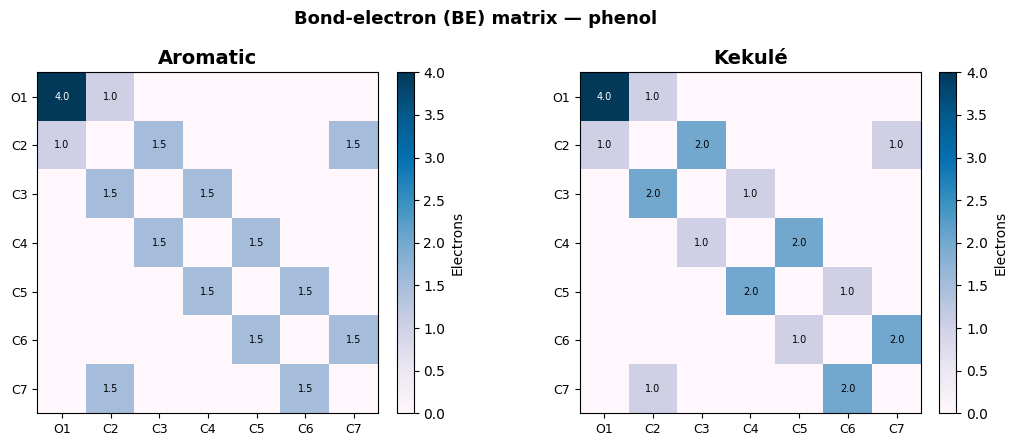

 Atom   Aromatic diag  Kekulé diag
    O1            4.00          4.0
    C2            0.00          0.0
    C3            0.00          0.0
    C4            0.00          0.0
    C5            0.00          0.0
    C6            0.00          0.0
    C7            0.00          0.0


In [23]:
import numpy as np

_VALENCE_ELECTRONS = {
    "H": 1,
    "C": 4,
    "N": 5,
    "O": 6,
    "F": 7,
    "P": 5,
    "S": 6,
    "Cl": 7,
    "Br": 7,
    "I": 7,
    "Si": 4,
    "B": 3,
}


def build_be_matrix(G: nx.Graph):
    ordered = sorted(G.nodes())
    idx = {node: i for i, node in enumerate(ordered)}
    n = len(ordered)
    B = np.zeros((n, n))

    for u, v, data in G.edges(data=True):
        order = float(data.get("order", 1.0))
        B[idx[u], idx[v]] = order
        B[idx[v], idx[u]] = order

    for node, data in G.nodes(data=True):
        el = data.get("element", "C")
        charge = int(data.get("formal_charge", 0))
        hcount = int(data.get("hcount", 0))
        val_e = _VALENCE_ELECTRONS.get(el, 0)
        bond_e = (
            sum(
                float(G.edges[node, nbr].get("order", 1.0)) for nbr in G.neighbors(node)
            )
            + hcount
        )
        B[idx[node], idx[node]] = max(val_e - charge - bond_e, 0)

    return B, ordered


# Aromatic form: ring bonds = 1.5
mol_be_arom = Chem.MolFromSmiles(Chem.CanonSmiles("c1ccccc1O"))

# Kekulé form: ring bonds = 1.0 / 2.0
mol_be_kek = Chem.MolFromSmiles(Chem.CanonSmiles("c1ccccc1O"))
Chem.Kekulize(mol_be_kek, clearAromaticFlags=True)

G_be_arom = mol_to_graph(mol_be_arom)
G_be_kek = mol_to_graph(mol_be_kek)

B_arom, ord_arom = build_be_matrix(G_be_arom)
B_kek, ord_kek = build_be_matrix(G_be_kek)


def _be_panel(ax, B, ordered, G, title):
    tick = [f"{G.nodes[n]['element']}{n}" for n in ordered]
    im = ax.imshow(B, cmap="PuBu", vmin=0)
    n = len(tick)
    ax.set_xticks(range(n))
    ax.set_xticklabels(tick, fontsize=9)
    ax.set_yticks(range(n))
    ax.set_yticklabels(tick, fontsize=9)
    for i in range(n):
        for j in range(n):
            val = B[i, j]
            if val > 0:
                ax.text(
                    j,
                    i,
                    f"{val:.1f}",
                    ha="center",
                    va="center",
                    fontsize=7,
                    color="white" if val > 3 else "black",
                )
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Electrons")
    ax.set_title(title, fontsize=14, fontweight="bold", pad=6)


fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle("Bond-electron (BE) matrix — phenol", fontsize=13, fontweight="bold")

_be_panel(
    axes[0],
    B_arom,
    ord_arom,
    G_be_arom,
    "Aromatic",
)
_be_panel(
    axes[1],
    B_kek,
    ord_kek,
    G_be_kek,
    "Kekulé",
)

plt.tight_layout()
plt.show()

print(f"{'Atom':>5}  {'Aromatic diag':>14}  {'Kekulé diag':>11}")
for n_a, n_k, v_a, v_k in zip(
    [f"{G_be_arom.nodes[n]['element']}{n}" for n in ord_arom],
    [f"{G_be_kek.nodes[n]['element']}{n}" for n in ord_kek],
    B_arom.diagonal(),
    B_kek.diagonal(),
):
    print(f"  {n_a:>4s}  {v_a:>14.2f}  {v_k:>11.1f}")

> **Stored in `synedu.Utils`** — `build_be_matrix` is also packaged for later graph-representation tasks:
> ```python
> from synedu.Utils.graph import build_be_matrix
> ```
> Later notebooks can reuse the same bond-electron matrix convention instead of redefining it.


**Q4 — Conversion**

**Goal**
Convert the SMILES below to a graph and back to SMILES.  
Explain **why the round-trip fails**.

```python
smiles = "c1cc[nH]c1"
```

<br>

<details>
<summary><b>Solution</b></summary>

```python
from rdkit import Chem

def naive_roundtrip(smiles: str) -> str:
    mol = Chem.MolFromSmiles(smiles)
    G = mol_to_graph(mol)
    mol2 = graph_to_mol(G)
    return Chem.MolToSmiles(mol2, canonical=True)

naive_roundtrip("c1cc[nH]c1")
>> 'c1ccnc1'
```
Why it fails

- `[nH]` is an aromatic nitrogen with an **explicit hydrogen**
- **Heavy-atom graphs discard hydrogens**
- RDKit cannot recover this on rebuild: `[nH] → [n]`
- This is **information loss by representation**, not a bug

> **Conclusion:** Heavy-atom graphs are **not information-complete** for SMILES round-trip.


</details> 

Since the hydrogen count is already stored in the graph (`hcount`), it can be
propagated back during molecule reconstruction:

```python
for node, data in G.nodes(data=True):
    n_h = int(data.get("hcount", 0))
    heavy_atom.SetNoImplicit(True)
    heavy_atom.SetNumExplicitHs(n_h)
```
This logic is exposed via:
```python
graph_to_mol(G, use_hcount=True)
```
With `use_hcount=True`, explicit hydrogens (e.g. `[nH]`) are preserved, making the
SMILES round-trip reversible.


In [24]:
from rdkit import Chem


def roundtrip(smiles: str) -> str:
    mol = Chem.MolFromSmiles(smiles)
    G = mol_to_graph(mol)
    mol2 = graph_to_mol(G, use_h_count=True)
    return Chem.MolToSmiles(mol2, canonical=True)


roundtrip("c1cc[nH]c1")

'c1cc[nH]c1'

**Q5 — Round-trip conversion**

**Goal.** Verify that SMILES in a DataFrame survive a  
SMILES → RDKit → graph → RDKit round-trip **without losing heavy-atom information**.

**Input.** A DataFrame `df` with:
- `smiles`: SMILES string  
- `name`: molecule name  

**Task.**
1. Implement `roundtrip_smiles_equal(smiles)` that:
   - parses a SMILES with RDKit,
   - converts it to a labeled graph (`mol_to_graph`),
   - reconstructs a molecule (`graph_to_mol`),
   - compares **canonical heavy-atom SMILES** (hydrogens removed).
2. Apply it to `df["smiles"]`.
3. Report molecules that fail the round-trip (if any).

---

<details>
<summary><b>Solution</b></summary>

```python
def standardize(smiles):
    return Chem.CanonSmiles(smiles, useChiral=False)


def roundtrip_smiles_equal(smiles: str) -> bool:
    new_smiles = roundtrip(smiles)
    return (
        standardize(new_smiles) == standardize(smiles)) 

df["ok"] = df["smiles"].apply(roundtrip_smiles_equal)
df.loc[~df["ok"], ["name", "smiles"]]
```
</details> 

<a id="s01-discussion"></a>

## 4. Discussion

- A **labeled graph morphism** provides a precise abstraction for
  structure- and attribute-preserving mappings, making the notion of
  “sameness” explicit and inspectable.

- Our **labeled molecular graph** adopts a deliberately minimal attribute
  schema (`element`, `formal_charge`, `aromatic`, `hcount`, `atom_map`,
  `order`). This strikes a
  balance between chemical faithfulness and algorithmic tractability:
  too few labels induce spurious symmetries, while too many hinder matching
  and reuse.

- **Round-trip conversion** (RDKit → NetworkX → RDKit) serves as a practical
  validation tool. While exact RDKit internal states need not be preserved,
  maintaining **heavy-atom topology and labels** ensures semantic
  equivalence and reproducibility.

<a id="5-quiz"></a>

## 5. Quiz

Answer briefly using what you learned about **RDKit**, **SMILES**, and **molecular graphs**.

1. What does RDKit molecule sanitization check, and why is it useful before graph conversion?
2. Why can one molecule have multiple valid SMILES strings, and what problem does canonical SMILES solve?
3. In a molecular graph, what do nodes and edges represent? Name two atom labels and one bond label that matter for matching.
4. When converting RDKit molecules to NetworkX graphs, what information is preserved, what may be simplified, and why is that acceptable for the later SynEdu tasks?


## 6. References

1. RDKit documentation. https://www.rdkit.org/docs/
2. Weininger, D. SMILES, a chemical language and information system. 1. Introduction to methodology and encoding rules. *Journal of Chemical Information and Computer Sciences* **28**, 31-36 (1988). https://doi.org/10.1021/ci00057a005
3. NetworkX documentation. https://networkx.org/documentation/stable/
4. Bonchev, D.; Rouvray, D. H., eds. *Chemical Graph Theory: Introduction and Fundamentals*. Abacus Press (1991).
5. Weininger, D.; Weininger, A.; Weininger, J. L. SMILES. 2. Algorithm for generation of unique SMILES notation. *Journal of Chemical Information and Computer Sciences* **29**, 97-101 (1989). https://doi.org/10.1021/ci00062a008
6. Morgan, H. L. The generation of a unique machine description for chemical structures: a technique developed at Chemical Abstracts Service. *Journal of Chemical Documentation* **5**, 107-113 (1965). https://doi.org/10.1021/c160017a018
7. Wiener, H. Structural determination of paraffin boiling points. *Journal of the American Chemical Society* **69**, 17-20 (1947). https://doi.org/10.1021/ja01193a005
8. Dugundji, J.; Ugi, I. An algebraic model of constitutional chemistry as a basis for chemical computer programs. *Topics in Current Chemistry* **39**, 19-64 (1973).
